<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/main/Semana_5_%22An%C3%A1lisis_de_texto%22_Marco_Antonio_Mu%C3%B1oz_Quiroz_261540.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

**Análisis de Texto**

---

**Universidad Autónoma de Ciudad Juárez (UACJ)**  
**Maestría en Inteligencia Artificial y Analítica de Datos**

---

**Materia:** Procesamiento de Lenguaje Natural  

---

**Autor:** *Marco Antonio Muñoz Quiroz*  
**Matrícula:** 261540  

---

**Fecha:** 22 de febrero de 2026

</div>


In [94]:
# ============================================================
#  Librerias
# ============================================================
import re
import unicodedata
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import spacy

In [95]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 75.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [96]:
# =============================
# texto que vamos a analizar
# =============================

texto = """

En el Congreso Internacional de Inteligencia Artificial 2025 se discutieron avances muy importantes.

@Maria comentó que la ética de la IA debe estar siempre en el centro de las investigaciones.

Puedes leer más en http://ia-congreso2025.org o enviar tus dudas al correo contacto@ia2025.org.

El Dr. Pérez afirmó: "¡La innovación no se detiene!". #InteligenciaArtificial #ÉticaDigital

Además, varios expertos señalaron que la inteligencia artificial, la inteligencia artificial

y la inteligencia artificial aparecen repetidamente en los debates académicos.
"""

In [97]:
# =============================
# cargar modelo de lenguaje
# =============================

def cargar_modelo():
    # aqui cargo el modelo de español de spacy para poder analizar texto
    return spacy.load("es_core_news_sm")

In [98]:
# =============================
# limpiar texto
# =============================

def limpiar_texto(texto):

    # quito links
    texto = re.sub(r"https?://\S+", " ", texto)

    # quito correos
    texto = re.sub(r"\S+@\S+", " ", texto)

    # quito menciones tipo @usuario
    texto = re.sub(r"@\w+", " ", texto)

    # quito simbolo hashtag pero dejo la palabra
    texto = texto.replace("#", " ")

    # paso todo a minusculas para uniformar
    texto = texto.lower()

    # quito espacios de mas
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()

In [99]:
# =============================
# convertir texto en tokens
# =============================

def tokenizar(nlp, texto):
    # spacy divide el texto en palabras
    doc = nlp(texto)
    return list(doc)

In [100]:
# =============================
# filtrar palabras innecesarias
# =============================

def filtrar_tokens(tokens):

    tokens_limpios = []

    for t in tokens:

        # ignoro signos espacios y stopwords
        if t.is_space or t.is_punct or t.is_stop:
            continue

        # tambien ignoro palabras demasiado cortas
        if len(t.text) <= 1:
            continue

        tokens_limpios.append(t)

    return tokens_limpios

In [101]:
# =============================
# lematizar palabras
# =============================

def lematizar(tokens):
    # aqui convierto cada palabra a su forma base
    return [t.lemma_ for t in tokens]

In [102]:
# =============================
# contar frecuencia de palabras
# =============================

def frecuencias(lista, top=10):
    # cuento cuantas veces aparece cada palabra
    conteo = Counter(lista)
    return conteo.most_common(top)

In [103]:
def graficar(datos, titulo):

    palabras = [x[0] for x in datos]
    valores = [x[1] for x in datos]

    # colores pastel
    colores = [
        "#AEC6CF",  # azul pastel
        "#FFB347",  # naranja pastel
        "#77DD77",  # verde pastel
        "#FF6961",  # rojo pastel
        "#CFCFC4",  # gris pastel
        "#F49AC2",  # rosa pastel
        "#B39EB5",  # morado pastel
        "#FFD1DC",  # rosa claro
        "#CB99C9",  # lavanda
        "#FDFD96"   # amarillo pastel
    ]

    # repetir colores si hay mas barras que colores
    colores = colores * (len(palabras)//len(colores) + 1)

    plt.figure(figsize=(10,5))

    plt.bar(palabras, valores, color=colores[:len(palabras)])

    # titulos y etiquetas
    plt.title(titulo, fontsize=16, fontweight="bold")
    plt.xlabel("palabras", fontsize=12)
    plt.ylabel("frecuencia", fontsize=12)

    # estilo visual
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [104]:
# =============================
# generar nube de palabras
# =============================

def nube_palabras(lista):

    texto = " ".join(lista)

    # aqui hago la nube rectangular cambiando el tamaño
    nube = WordCloud(
        width=1200,      # ancho grande
        height=400,      # alto pequeño -> forma rectangular
        background_color="white",
        collocations=False
    ).generate(texto)

    plt.figure(figsize=(10,4))  # figura tambien rectangular
    plt.imshow(nube)
    plt.axis("off")
    plt.title("nube de palabras", fontsize=16, fontweight="bold")
    plt.show()


top palabras
inteligencia 4
artificial 4
congreso 1
internacional 1
2025 1
discutieron 1
avances 1
importantes 1
ética 1
ia 1

top lemas
inteligencia 4
artificial 4
congreso 1
internacional 1
2025 1
discutir 1
avance 1
importante 1
ética 1
ia 1


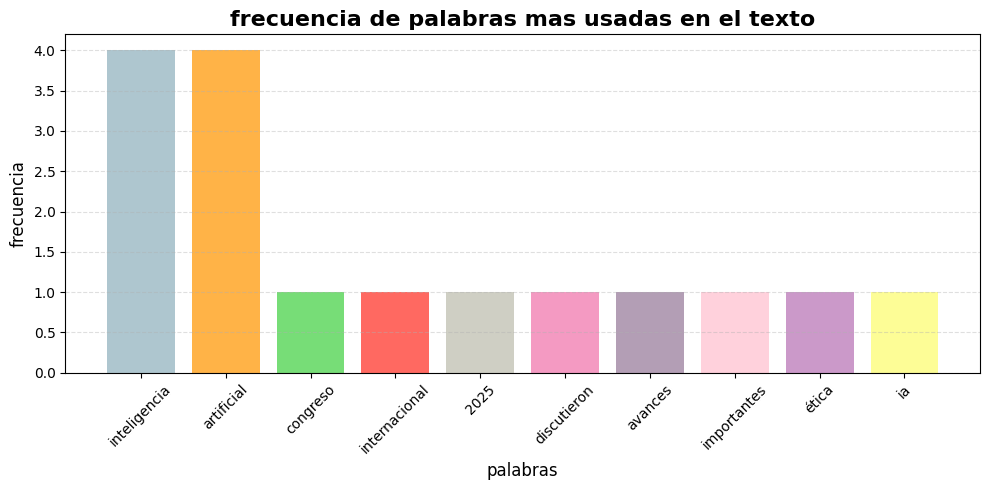

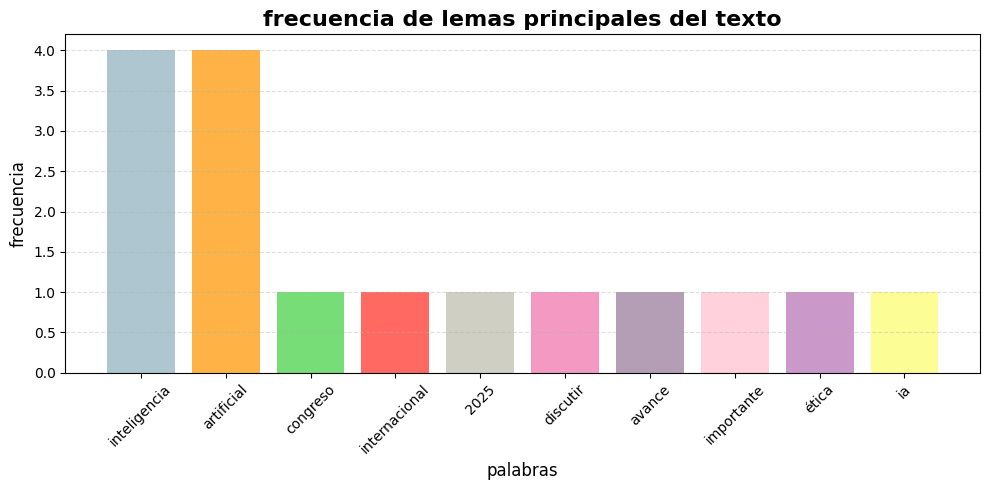

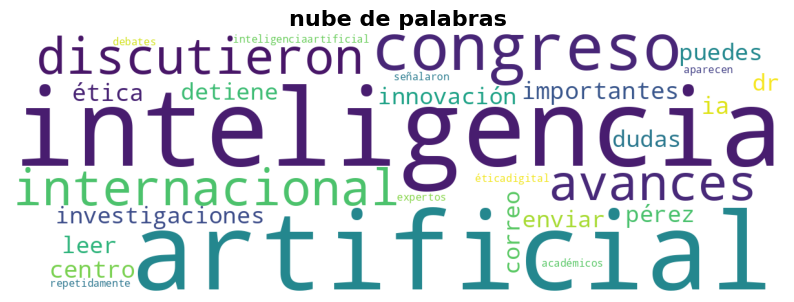

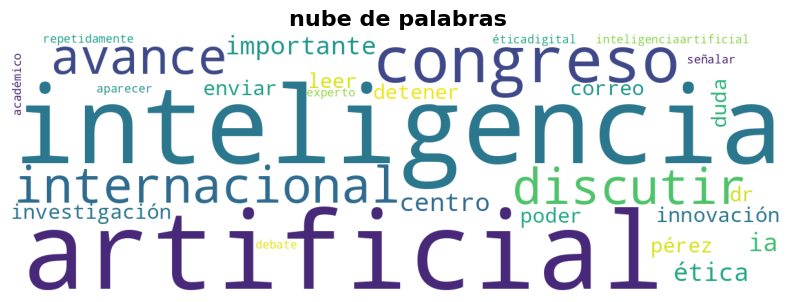

In [110]:
def main():

    # cargo modelo
    nlp = cargar_modelo()

    # limpio texto
    texto_limpio = limpiar_texto(texto)

    # tokenizo
    tokens = tokenizar(nlp, texto_limpio)

    # filtro palabras inutiles
    tokens_filtrados = filtrar_tokens(tokens)

    # lista de palabras sin lematizar
    palabras = [t.text for t in tokens_filtrados]

    # lemas
    lemas = lematizar(tokens_filtrados)

    # calculo frecuencias
    freq_palabras = frecuencias(palabras)
    freq_lemas = frecuencias(lemas)

    # imprimo resultados
    print("\ntop palabras")
    for w,c in freq_palabras:
        print(w, c)

    print("\ntop lemas")
    for w,c in freq_lemas:
        print(w, c)

    # graficas
    graficar(freq_palabras, "frecuencia de palabras mas usadas en el texto")
    graficar(freq_lemas, "frecuencia de lemas principales del texto")

    # nubes
    nube_palabras(palabras)
    nube_palabras(lemas)

    reporte = "resultados analisis\n\n"

# ejecutar programa
main()